# No-Cluster Hyperparameter Notebook: AdaBoost Perceptron


In [ ]:
import sys
from pathlib import Path
from time import perf_counter
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, PowerTransformer, RobustScaler, StandardScaler
from sklearn.svm import SVC

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from HCD_utils import get_merged_data_w_ids, plot_auc_curves
from HyperparameterTuning import tune_hyperparameters


In [ ]:
RANDOM_STATE = 42 #43
MODEL_KEY = "adaboost_perceptron"
NUMERIC_TRANSFORM = 'standard_scaler' #"sqrt"
CATEGORICAL_ENCODER = "one_hot"
CLIP_OUTLIERS = True
IQR_MULTIPLIER = 3.0
MAX_TRAIN_OBS = None
TARGET_METRICS = ['recall', 'precision', 'f1', 'roc_auc']
POLY = True # False

TOTAL_THREADS = 16
NUM_CURRENT_NOTEBOOKS = 4
THREADS_PER_NOTEBOOK = max(1, TOTAL_THREADS // max(1, NUM_CURRENT_NOTEBOOKS))

SMOKE_MODE = False

print("Configuration:")
print({
    "MODEL_KEY": MODEL_KEY,
    "NUMERIC_TRANSFORM": NUMERIC_TRANSFORM,
    "CATEGORICAL_ENCODER": CATEGORICAL_ENCODER,
    "CLIP_OUTLIERS": CLIP_OUTLIERS,
    "IQR_MULTIPLIER": IQR_MULTIPLIER,
    "MAX_TRAIN_OBS": MAX_TRAIN_OBS,
    "TARGET_METRICS": TARGET_METRICS,
    "THREADS_PER_NOTEBOOK": THREADS_PER_NOTEBOOK,
    "SMOKE_MODE": SMOKE_MODE,
})


Configuration:
{'MODEL_KEY': 'adaboost_perceptron', 'NUMERIC_TRANSFORM': 'sqrt', 'CATEGORICAL_ENCODER': 'one_hot', 'CLIP_OUTLIERS': True, 'IQR_MULTIPLIER': 3.0, 'MAX_TRAIN_OBS': None, 'TARGET_METRICS': ['recall', 'precision', 'f1', 'roc_auc'], 'THREADS_PER_NOTEBOOK': 4, 'SMOKE_MODE': False}


In [ ]:
# Runtime note (Big-O aware)
# 1) Randomized search is O(n_random_iterations * fit_time)
# 2) Explicit grid can be O(product_of_grid_sizes * fit_time), so grids are intentionally compact
# 3) MLP/SVC have higher fit complexity on large N, so MAX_TRAIN_OBS caps are applied when configured


In [ ]:
with ZipFile("archive (10).zip", mode="r") as project_data:
    with project_data.open("hospital_deterioration_hourly_panel.csv", mode="r") as f:
        deterioration_hourly_panel = pd.read_csv(f)
    with project_data.open("hospital_deterioration_ml_ready.csv", mode="r") as f:
        deterioration_ml_ready = pd.read_csv(f)
    with project_data.open("labs_timeseries.csv", mode="r") as f:
        labs_timeseries = pd.read_csv(f)
    with project_data.open("patients.csv", mode="r") as f:
        patients = pd.read_csv(f)
    with project_data.open("vitals_timeseries.csv", mode="r") as f:
        vitals_timeseries = pd.read_csv(f)


datasets = [
    deterioration_hourly_panel,
    labs_timeseries,
    patients,
    vitals_timeseries,
]

joined_data, report = get_merged_data_w_ids(
    kwargs=datasets,
    join_cols=["patient_id", "hour_from_admission"],
    how="left",
    strict=True,
    return_report=True,
)
if POLY==True:
    for col in joined_data.select_dtypes(['number']).columns:
        for pow in [2,3]:
            new_header = f'{col}_**{pow}'
            joined_data[new_header] = joined_data[col]**pow

filtered_data = joined_data.loc[
    (joined_data["hour_from_admission"] < joined_data["deterioration_hour"])
    | (joined_data["deterioration_hour"] == -1)
].copy()
filtered_data = filtered_data[deterioration_ml_ready.columns].copy()

print("Filtered shape:", filtered_data.shape)
print("Class counts (original):")
print(filtered_data["deterioration_next_12h"].value_counts())


Filtered shape: (382548, 22)
Class counts (original):
deterioration_next_12h
0    359959
1     22589
Name: count, dtype: int64


In [ ]:
def recall_precision_accuracy_score(y_true, y_pred):
    rec = recall_score(y_true, y_pred, zero_division=0)
    pre = precision_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return (100.0 * rec) + (10.0 * pre) + acc


def balance_binary_classes_equal_false_true(X, y, true_label=1, false_label=0, random_state=43):
    y_arr = np.asarray(y)
    true_idx = np.where(y_arr == true_label)[0]
    false_idx = np.where(y_arr == false_label)[0]

    if len(true_idx) == 0 or len(false_idx) == 0:
        raise ValueError("Both classes must be present to balance data.")

    take_false = min(len(false_idx), len(true_idx))
    rng = np.random.default_rng(random_state)
    sampled_false = rng.choice(false_idx, size=take_false, replace=False)
    kept_idx = np.concatenate([true_idx, sampled_false])
    rng.shuffle(kept_idx)

    X_bal = X.iloc[kept_idx] if hasattr(X, "iloc") else X[kept_idx]
    y_bal = y.iloc[kept_idx] if hasattr(y, "iloc") else y_arr[kept_idx]
    return X_bal, y_bal


def cap_rows_stratified(X, y, max_rows, random_state=43):
    if max_rows is None or len(X) <= max_rows:
        return X, y
    X_cap, _, y_cap, _ = train_test_split(
        X,
        y,
        train_size=max_rows,
        random_state=random_state,
        stratify=y,
    )
    return X_cap, y_cap


def apply_iqr_clip_fit(df_num, multiplier=3.0):
    q1 = df_num.quantile(0.25)
    q3 = df_num.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return lower, upper


def apply_iqr_clip_transform(df_num, lower, upper):
    return df_num.clip(lower=lower, upper=upper, axis=1)


def make_numeric_transformer(transform_name):
    if transform_name == "robust_scaler":
        return RobustScaler()
    if transform_name == "standard_scaler":
        return StandardScaler()
    if transform_name == "power":
        return PowerTransformer(method="yeo-johnson")
    if transform_name == "sqrt":
        return FunctionTransformer(lambda x: np.sign(x) * np.sqrt(np.abs(x)), validate=False)
    if transform_name == "custom":
        return FunctionTransformer(lambda x: x / (1.0 + np.abs(x)), validate=False)
    raise ValueError(f"Unknown numeric transform: {transform_name}")


def make_categorical_encoder(encoder_name):
    if encoder_name == "one_hot":
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)
    if encoder_name == "ordinal":
        return OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    raise ValueError(f"Unknown categorical encoder: {encoder_name}")


def build_preprocessor(X_train, numeric_transform, categorical_encoder, clip_outliers, iqr_multiplier=3.0):
    numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    num_imputer = SimpleImputer(strategy="median")
    cat_imputer = SimpleImputer(strategy="most_frequent")

    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index) if numeric_cols else pd.DataFrame(index=X_train.index)
    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[categorical_cols]), columns=categorical_cols, index=X_train.index) if categorical_cols else pd.DataFrame(index=X_train.index)

    clip_bounds = None
    if clip_outliers and numeric_cols:
        lower, upper = apply_iqr_clip_fit(X_train_num, multiplier=iqr_multiplier)
        X_train_num = apply_iqr_clip_transform(X_train_num, lower, upper)
        clip_bounds = (lower, upper)

    num_transformer = make_numeric_transformer(numeric_transform)
    num_transformer.fit(X_train_num.values) if numeric_cols else None

    encoder = make_categorical_encoder(categorical_encoder)
    encoder.fit(X_train_cat.values) if categorical_cols else None

    return {
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "num_imputer": num_imputer,
        "cat_imputer": cat_imputer,
        "clip_bounds": clip_bounds,
        "num_transformer": num_transformer,
        "encoder": encoder,
    }


def transform_with_preprocessor(X, prep):
    numeric_cols = prep["numeric_cols"]
    categorical_cols = prep["categorical_cols"]

    X_num = pd.DataFrame(prep["num_imputer"].transform(X[numeric_cols]), columns=numeric_cols, index=X.index) if numeric_cols else pd.DataFrame(index=X.index)
    X_cat = pd.DataFrame(prep["cat_imputer"].transform(X[categorical_cols]), columns=categorical_cols, index=X.index) if categorical_cols else pd.DataFrame(index=X.index)

    if prep["clip_bounds"] is not None and numeric_cols:
        lower, upper = prep["clip_bounds"]
        X_num = apply_iqr_clip_transform(X_num, lower, upper)

    X_num_proc = prep["num_transformer"].transform(X_num.values) if numeric_cols else np.empty((len(X), 0))
    X_cat_proc = prep["encoder"].transform(X_cat.values) if categorical_cols else np.empty((len(X), 0))

    if hasattr(X_cat_proc, "toarray"):
        X_cat_proc = X_cat_proc.toarray()

    return np.hstack([X_num_proc, X_cat_proc]).astype(np.float32, copy=False)


def predict_scores(model, X_values):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_values)
        if probs.ndim == 2 and probs.shape[1] > 1:
            return probs[:, 1]
        return probs.ravel()
    if hasattr(model, "decision_function"):
        return model.decision_function(X_values)
    return model.predict(X_values)


def compute_metrics(y_true, y_pred, y_score):
    return {
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


In [ ]:
target_col = "deterioration_next_12h"
feature_cols = [c for c in filtered_data.columns if c != target_col]

X_all_unbalanced = filtered_data[feature_cols].copy()
y_all_unbalanced = filtered_data[target_col].astype(int).copy()

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_all_unbalanced,
    y_all_unbalanced,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_all_unbalanced,
)

X_train_bal, y_train_bal = balance_binary_classes_equal_false_true(
    X_train_raw,
    y_train_raw,
    true_label=1,
    false_label=0,
    random_state=RANDOM_STATE,
)

X_train_bal, y_train_bal = cap_rows_stratified(
    X_train_bal,
    y_train_bal,
    max_rows=MAX_TRAIN_OBS,
    random_state=RANDOM_STATE,
)

X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train_bal,
    y_train_bal,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_bal,
)

prep = build_preprocessor(
    X_tune_train,
    numeric_transform=NUMERIC_TRANSFORM,
    categorical_encoder=CATEGORICAL_ENCODER,
    clip_outliers=CLIP_OUTLIERS,
    iqr_multiplier=IQR_MULTIPLIER,
)

X_tune_proc = transform_with_preprocessor(X_tune_train, prep)
X_val_proc = transform_with_preprocessor(X_val, prep)
X_train_proc = transform_with_preprocessor(X_train_bal, prep)
X_test_proc = transform_with_preprocessor(X_test_raw, prep)
X_unbalanced_proc = transform_with_preprocessor(X_all_unbalanced, prep)

print("Shapes:")
print("X_tune_proc:", X_tune_proc.shape)
print("X_val_proc:", X_val_proc.shape)
print("X_train_proc (balanced full train):", X_train_proc.shape)
print("X_test_proc:", X_test_proc.shape)
print("X_unbalanced_proc (full pre-split):", X_unbalanced_proc.shape)


Shapes:
X_tune_proc: (25413, 28)
X_val_proc: (8471, 28)
X_train_proc (balanced full train): (33884, 28)
X_test_proc: (95637, 28)
X_unbalanced_proc (full pre-split): (382548, 28)


In [ ]:
def make_estimator_and_grids(model_key, threads_per_notebook, random_state=43):
    if model_key == "xgboost":
        from xgboost import XGBClassifier
        estimator = XGBClassifier(
            random_state=random_state,
            n_jobs=threads_per_notebook,
            eval_metric="logloss",
            tree_method="hist",
            verbosity=0,
        )
        random_dist = {
            "n_estimators": randint(120, 260),
            "max_depth": randint(3, 9),
            "learning_rate": loguniform(0.02, 0.2),
            "subsample": [0.7, 0.8, 0.9],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "min_child_weight": randint(1, 6),
            "reg_lambda": loguniform(0.5, 5.0),
        }
        explicit_grid = {
            "n_estimators": [140, 180, 220],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.04, 0.08, 0.12],
            "subsample": [0.8, 0.9],
            "colsample_bytree": [0.8, 0.9],
            "min_child_weight": [1, 3],
        }
        return estimator, random_dist, explicit_grid, 24, 120

    if model_key == "random_forest":
        estimator = RandomForestClassifier(
            random_state=random_state,
            n_jobs=threads_per_notebook,
        )
        random_dist = {
            "n_estimators": randint(80, 260),
            "max_depth": [8, 12, 16, 20, None],
            "min_samples_split": randint(2, 24),
            "min_samples_leaf": randint(1, 8),
            "max_features": ["sqrt", "log2"],
            "class_weight": [None, "balanced", "balanced_subsample"],
        }
        explicit_grid = {
            "n_estimators": [120, 180, 240],
            "max_depth": [10, 14, 18],
            "min_samples_split": [2, 8, 16],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt"],
            "class_weight": [None, "balanced"],
        }
        return estimator, random_dist, explicit_grid, 24, 140

    if model_key == "adaboost_logistic":
        base = LogisticRegression(
            solver="lbfgs",
            penalty="l2",
            random_state=random_state,
        )
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(20, 90),
            "learning_rate": loguniform(0.03, 0.8),
            "estimator__C": loguniform(1e-2, 2e1),
            "estimator__max_iter": randint(300, 1800),
        }
        explicit_grid = {
            "n_estimators": [30, 50, 70],
            "learning_rate": [0.15, 0.3, 0.5],
            "estimator__C": [0.3, 1.0, 3.0, 8.0],
            "estimator__max_iter": [800, 1200, 1600],
        }
        return estimator, random_dist, explicit_grid, 24, 120

    if model_key == "adaboost_mlp":
        base = MLPClassifier(
            random_state=random_state,
            early_stopping=True,
        )
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(15, 60),
            "learning_rate": loguniform(0.03, 0.7),
            "estimator__hidden_layer_sizes": [(8,), (16,), (16, 8), (12, 6)],
            "estimator__activation": ["relu", "tanh"],
            "estimator__alpha": loguniform(1e-5, 1e-2),
            "estimator__learning_rate_init": loguniform(1e-4, 5e-3),
            "estimator__max_iter": randint(300, 900),
        }
        explicit_grid = {
            "n_estimators": [20, 35, 50],
            "learning_rate": [0.1, 0.25, 0.5],
            "estimator__hidden_layer_sizes": [(8,), (16,), (16, 8)],
            "estimator__activation": ["relu", "tanh"],
            "estimator__alpha": [1e-4, 1e-3],
            "estimator__learning_rate_init": [5e-4, 1e-3],
            "estimator__max_iter": [500, 700],
        }
        return estimator, random_dist, explicit_grid, 20, 90

    if model_key == "adaboost_perceptron":
        base = Perceptron(random_state=random_state)
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(20, 90),
            "learning_rate": loguniform(0.03, 0.8),
            "estimator__penalty": [None, "l2", "l1", "elasticnet"],
            "estimator__alpha": loguniform(1e-6, 1e-2),
            "estimator__max_iter": randint(600, 2000),
            "estimator__eta0": loguniform(1e-3, 1.0),
        }
        explicit_grid = {
            "n_estimators": [30, 50, 70],
            "learning_rate": [0.1, 0.25, 0.5],
            "estimator__penalty": [None, "l2", "elasticnet"],
            "estimator__alpha": [1e-5, 1e-4, 1e-3],
            "estimator__max_iter": [1000, 1600],
            "estimator__eta0": [0.01, 0.05, 0.1],
        }
        return estimator, random_dist, explicit_grid, 24, 120

    if model_key == "adaboost_svc":
        base = SVC(probability=True, random_state=random_state)
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(12, 40),
            "learning_rate": loguniform(0.03, 0.6),
            "estimator__C": loguniform(1e-1, 1e2),
            "estimator__kernel": ["linear", "rbf"],
            "estimator__gamma": loguniform(1e-4, 1e-1),
        }
        explicit_grid = {
            "n_estimators": [12, 20, 30],
            "learning_rate": [0.08, 0.2, 0.4],
            "estimator__C": [0.5, 2.0, 8.0, 20.0],
            "estimator__kernel": ["linear", "rbf"],
            "estimator__gamma": [0.001, 0.01, 0.05],
        }
        return estimator, random_dist, explicit_grid, 18, 70

    raise ValueError(f"Unsupported model_key: {model_key}")


In [ ]:
estimator, random_param_distributions, explicit_param_grid, n_random_iterations, max_combinations_tested = make_estimator_and_grids(
    MODEL_KEY,
    THREADS_PER_NOTEBOOK,
    random_state=RANDOM_STATE,
)

if SMOKE_MODE:
    n_random_iterations = min(6, n_random_iterations)
    max_combinations_tested = min(30, max_combinations_tested)

print("Tuning budget:")
print({
    "n_random_iterations": n_random_iterations,
    "max_combinations_tested": max_combinations_tested,
})

start = perf_counter()
tuning_results = tune_hyperparameters(
    estimator=estimator,
    X_train=X_tune_proc,
    y_train=y_tune_train,
    X_val=X_val_proc,
    y_val=y_val,
    score_fn=recall_precision_accuracy_score,
    random_param_distributions=random_param_distributions,
    explicit_param_grid=explicit_param_grid,
    run_randomized=True,
    run_explicit=True,
    n_random_iterations=n_random_iterations,
    random_state=RANDOM_STATE,
    top_k_random=1,
    max_combinations_tested=max_combinations_tested,
    save_results=None,
    overwrite=True,
)
print(f"Tuning completed in {(perf_counter() - start) / 60:.2f} minutes")


Tuning budget:
{'n_random_iterations': 24, 'max_combinations_tested': 120}
Tuning completed in 10.42 minutes


In [ ]:
def collect_candidate_params(tuning_results):
    candidate_params = []
    for stage in ("randomized", "grid"):
        stage_res = tuning_results.get(stage)
        if stage_res and stage_res.get("results"):
            candidate_params.extend([r["params"] for r in stage_res["results"]])

    if tuning_results.get("best_overall_params"):
        candidate_params.append(tuning_results["best_overall_params"])

    seen = set()
    unique_params = []
    for params in candidate_params:
        key = tuple(sorted(params.items()))
        if key not in seen:
            seen.add(key)
            unique_params.append(params)
    return unique_params


def score_model_by_metric(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_score = predict_scores(model, X_eval)
    metrics = compute_metrics(y_eval, y_pred, y_score)
    return metrics


candidate_params = collect_candidate_params(tuning_results)
if not candidate_params:
    raise RuntimeError("No candidate hyperparameters found from tuning results.")

best_by_metric = {m: {"score": -np.inf, "params": None} for m in TARGET_METRICS}

for params in candidate_params:
    try:
        model = clone(estimator).set_params(**params)
        model.fit(X_tune_proc, y_tune_train)
        metrics = score_model_by_metric(model, X_val_proc, y_val)
        for metric in TARGET_METRICS:
            score = metrics[metric]
            if score > best_by_metric[metric]["score"]:
                best_by_metric[metric] = {"score": score, "params": params}
    except Exception:
        continue

print("Best validation params by metric:")
for metric in TARGET_METRICS:
    print(f"\n{metric}: {best_by_metric[metric]['score']:.4f}")
    print(best_by_metric[metric]["params"])


Best validation params by metric:

recall: 1.0000
{'estimator__alpha': np.float64(1.7054000015759993e-05), 'estimator__eta0': np.float64(0.065239122048401), 'estimator__max_iter': 1161, 'estimator__penalty': 'l1', 'learning_rate': np.float64(0.3264249903932064), 'n_estimators': 83}

precision: 0.9734
{'estimator__alpha': 1e-05, 'estimator__eta0': 0.1, 'estimator__max_iter': 1000, 'estimator__penalty': 'elasticnet', 'learning_rate': 0.25, 'n_estimators': 30}

f1: 0.8462
{'estimator__alpha': np.float64(4.128826827265449e-05), 'estimator__eta0': np.float64(0.008527241847978064), 'estimator__max_iter': 1904, 'estimator__penalty': None, 'learning_rate': np.float64(0.2068898719796122), 'n_estimators': 56}

roc_auc: 0.9299
{'estimator__alpha': np.float64(0.0017544684707382588), 'estimator__eta0': np.float64(0.0016758072337768075), 'estimator__max_iter': 1455, 'estimator__penalty': None, 'learning_rate': np.float64(0.03299848954349164), 'n_estimators': 70}


In [ ]:
metric_models = {}
metric_reports = {}

for metric in TARGET_METRICS:
    params = best_by_metric[metric]["params"]
    if params is None:
        raise RuntimeError(f"No params selected for metric: {metric}")

    model = clone(estimator).set_params(**params)
    model.fit(X_train_proc, y_train_bal)
    metric_models[metric] = model

    train_pred = model.predict(X_train_proc)
    train_score = predict_scores(model, X_train_proc)

    test_pred = model.predict(X_test_proc)
    test_score = predict_scores(model, X_test_proc)

    unbalanced_pred = model.predict(X_unbalanced_proc)
    unbalanced_score = predict_scores(model, X_unbalanced_proc)

    train_metrics = compute_metrics(y_train_bal, train_pred, train_score)
    test_metrics = compute_metrics(y_test, test_pred, test_score)
    unbalanced_metrics = compute_metrics(y_all_unbalanced, unbalanced_pred, unbalanced_score)

    rows = []
    for split_name, metric_values in [
        ("train_balanced", train_metrics),
        ("test", test_metrics),
        ("full_pre_split_unbalanced", unbalanced_metrics),
    ]:
        row = {"split": split_name}
        row.update(metric_values)
        rows.append(row)

    report_df = pd.DataFrame(rows)
    metric_reports[metric] = report_df

    print("=" * 70)
    print(f"Best model for {metric.upper()}")
    print("best_params:")
    print(params)
    print(report_df.to_string(index=False))

summary_rows = []
for metric, report_df in metric_reports.items():
    test_row = report_df.loc[report_df["split"] == "test"].iloc[0]
    summary_rows.append(
        {
            "selected_for": metric,
            "test_recall": test_row["recall"],
            "test_precision": test_row["precision"],
            "test_f1": test_row["f1"],
            "test_roc_auc": test_row["roc_auc"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
print("\nTest-set summary across selected metric-best models:")
display(summary_df)


Best model for RECALL
best_params:
{'estimator__alpha': np.float64(1.7054000015759993e-05), 'estimator__eta0': np.float64(0.065239122048401), 'estimator__max_iter': 1161, 'estimator__penalty': 'l1', 'learning_rate': np.float64(0.3264249903932064), 'n_estimators': 83}
                    split  recall  precision  f1  roc_auc
           train_balanced     0.0        0.0 0.0      0.5
                     test     0.0        0.0 0.0      0.5
full_pre_split_unbalanced     0.0        0.0 0.0      0.5
Best model for PRECISION
best_params:
{'estimator__alpha': 1e-05, 'estimator__eta0': 0.1, 'estimator__max_iter': 1000, 'estimator__penalty': 'elasticnet', 'learning_rate': 0.25, 'n_estimators': 30}
                    split   recall  precision       f1  roc_auc
           train_balanced 0.773758   0.750157 0.761775 0.810332
                     test 0.778998   0.160202 0.265752 0.813461
full_pre_split_unbalanced 0.775068   0.159423 0.264451 0.811064
Best model for F1
best_params:
{'estimator__al

,selected_for,test_recall,test_precision,test_f1,test_roc_auc
0,recall,0.000000,0.000000,0.000000,0.500000
1,precision,0.778998,0.160202,0.265752,0.813461
2,f1,0.793519,0.337755,0.473829,0.930412
3,roc_auc,0.811050,0.318056,0.456926,0.933174


ROC curves for model selected by RECALL
{'train_balanced': 0.5, 'test': 0.5, 'full_pre_split_unbalanced': 0.5}
PR curves for model selected by RECALL
{'train_balanced': 0.5, 'test': 0.05904618505390173, 'full_pre_split_unbalanced': 0.059048799104948924}
ROC curves for model selected by PRECISION
{'train_balanced': 0.8103318980848379, 'test': 0.8134607099665344, 'full_pre_split_unbalanced': 0.8110642706950826}
PR curves for model selected by PRECISION
{'train_balanced': 0.7808440325697356, 'test': 0.2260541040493349, 'full_pre_split_unbalanced': 0.22467261145355455}
ROC curves for model selected by F1
{'train_balanced': 0.9277345767691088, 'test': 0.9304120444840958, 'full_pre_split_unbalanced': 0.9285211451776042}
PR curves for model selected by F1
{'train_balanced': 0.9271942787440652, 'test': 0.6265440648682213, 'full_pre_split_unbalanced': 0.6187762742462248}
ROC curves for model selected by ROC_AUC
{'train_balanced': 0.9313030021346379, 'test': 0.9331737949829856, 'full_pre_split_u

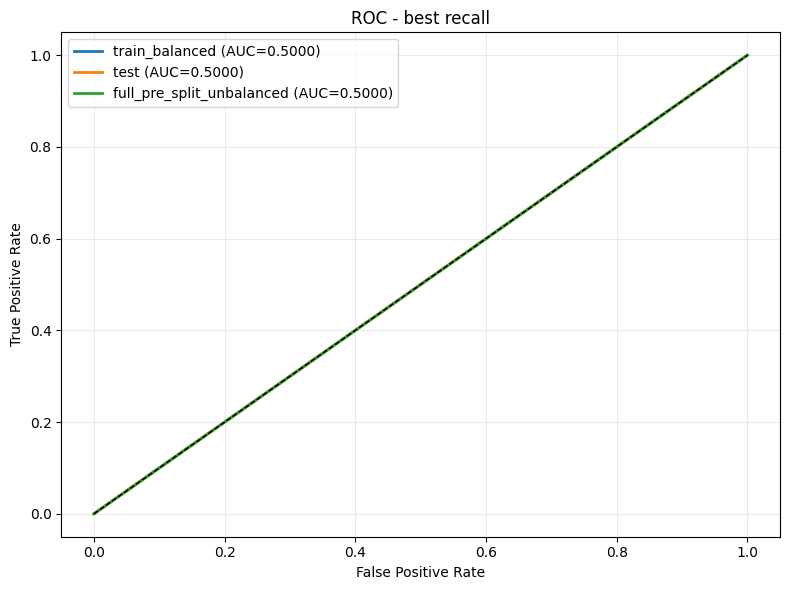

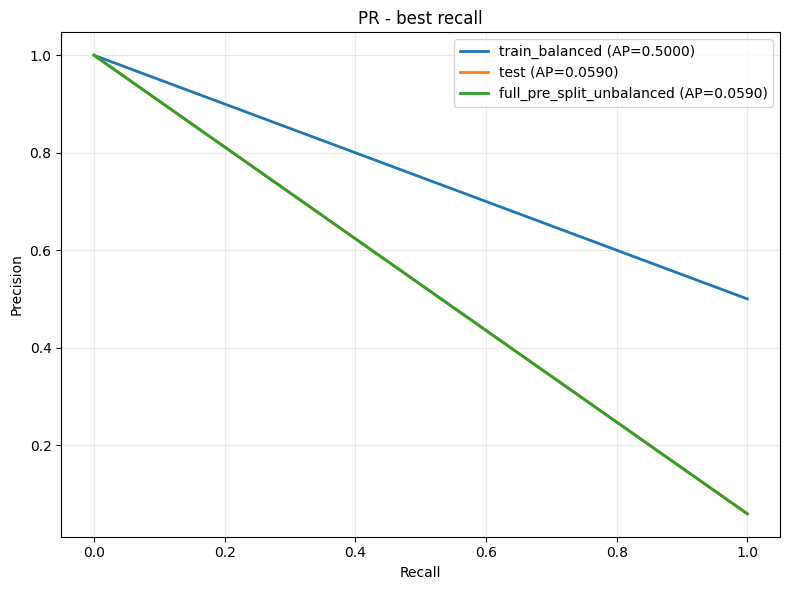

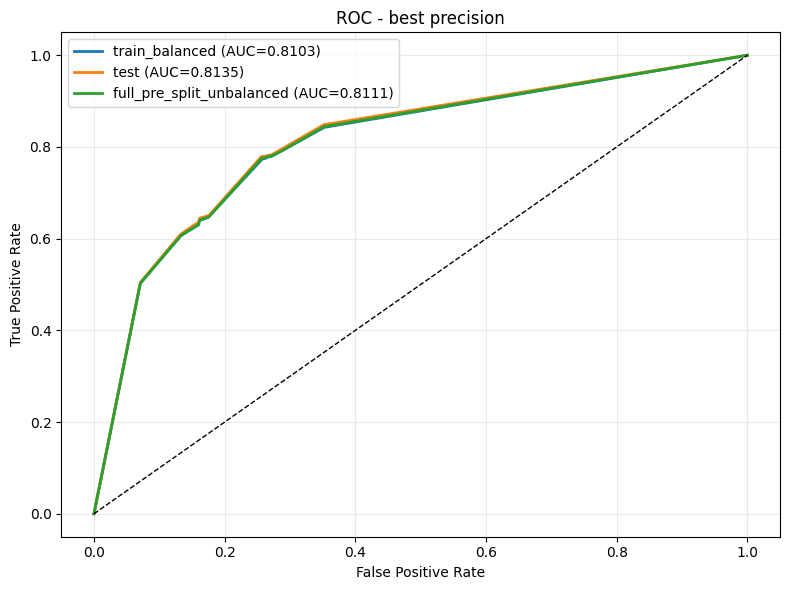

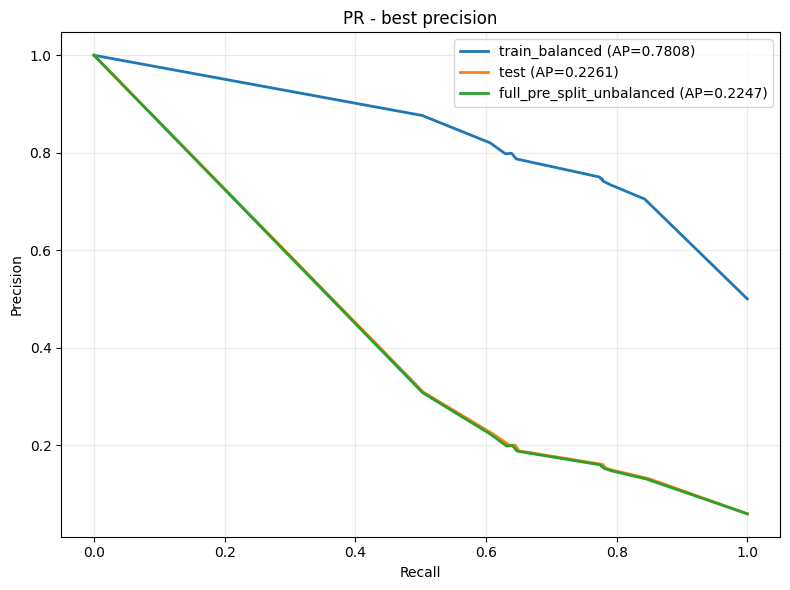

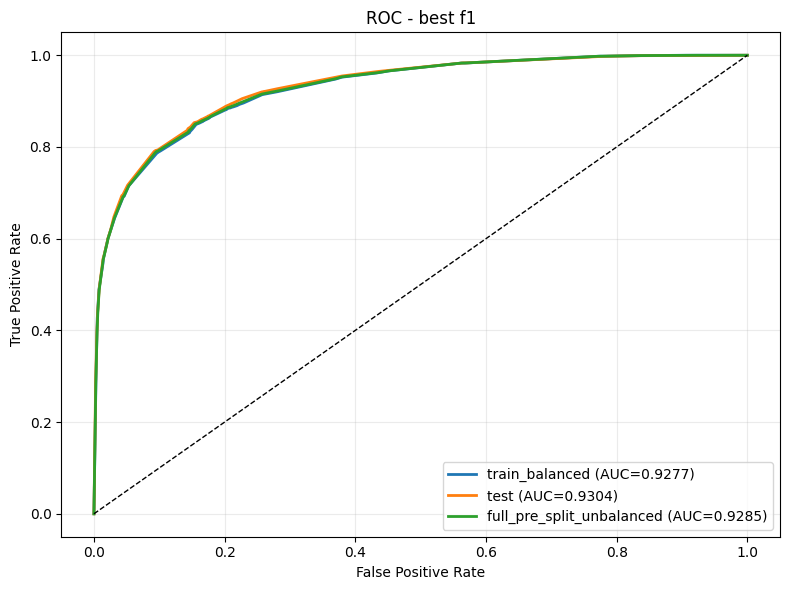

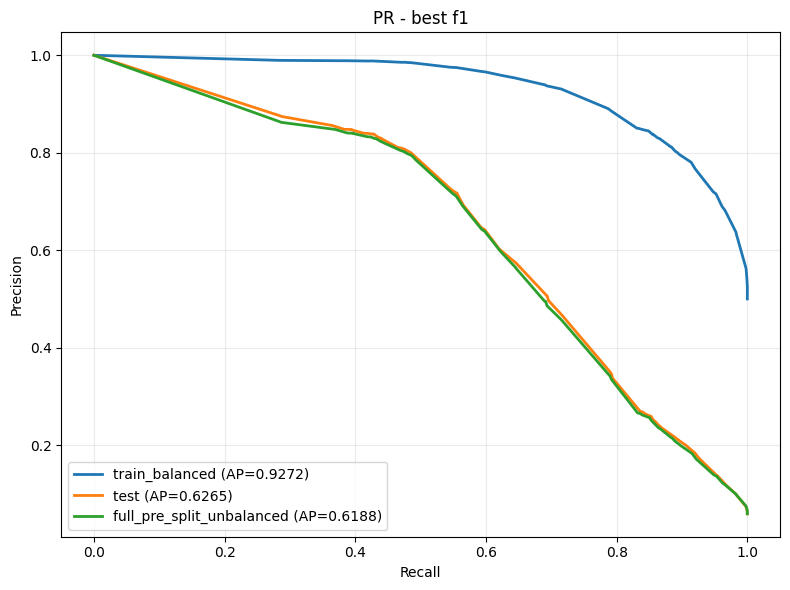

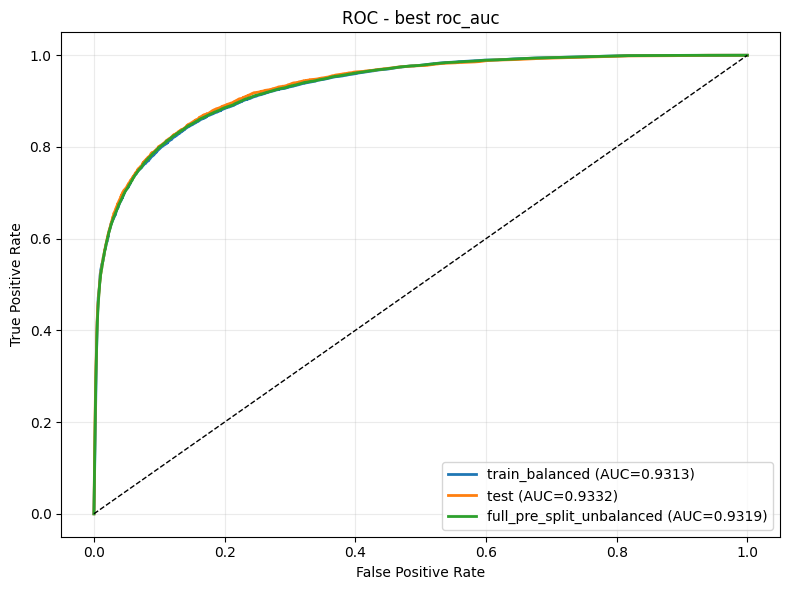

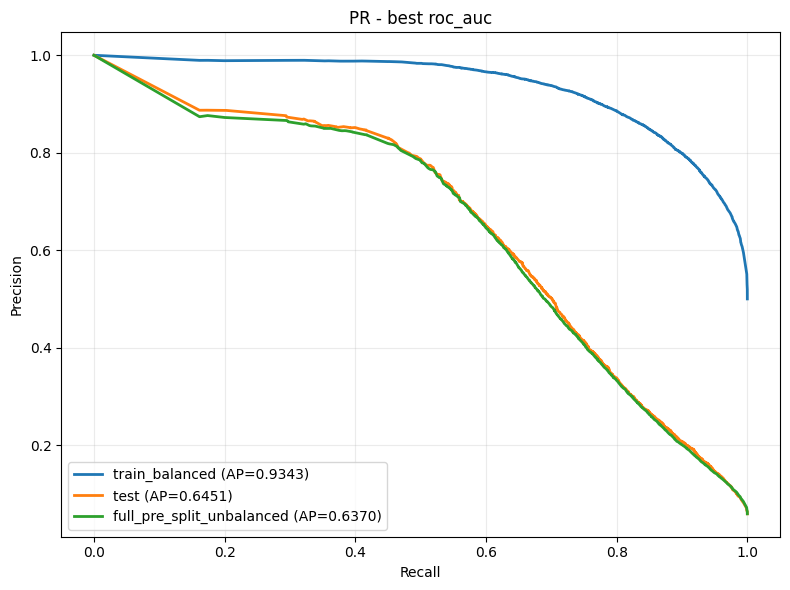

In [ ]:
for metric, model in metric_models.items():
    train_scores = predict_scores(model, X_train_proc)
    test_scores = predict_scores(model, X_test_proc)
    unbalanced_scores = predict_scores(model, X_unbalanced_proc)

    print("=" * 70)
    print(f"ROC curves for model selected by {metric.upper()}")
    _, _, aucs = plot_auc_curves(
        [y_train_bal, y_test, y_all_unbalanced],
        [train_scores, test_scores, unbalanced_scores],
        names=["train_balanced", "test", "full_pre_split_unbalanced"],
        curve="roc",
        title=f"ROC - best {metric}",
    )
    print(aucs)

    print(f"PR curves for model selected by {metric.upper()}")
    _, _, pr_aucs = plot_auc_curves(
        [y_train_bal, y_test, y_all_unbalanced],
        [train_scores, test_scores, unbalanced_scores],
        names=["train_balanced", "test", "full_pre_split_unbalanced"],
        curve="pr",
        title=f"PR - best {metric}",
    )
    print(pr_aucs)
